# Import required libraries

In [1]:
import os
import numpy as np
import json
import matplotlib.pyplot as plt
import shutil
import seaborn as sns
from PIL import Image
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.layers import Rescaling, Lambda
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Initialise image data generator

In [2]:
train_data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_data_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


# Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

!mkdir {HOME}/datasets
%cd {HOME}/datasets

!unzip /content/gdrive/MyDrive/emotion.zip

Streaming output truncated to the last 5000 lines.
  inflating: emotion/train/angry/Training_81541574.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_81541574.jpg  
  inflating: emotion/train/angry/Training_50120123.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_50120123.jpg  
  inflating: emotion/train/angry/Training_60016886.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_60016886.jpg  
  inflating: emotion/train/angry/Training_68690730.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_68690730.jpg  
  inflating: emotion/train/angry/Training_73515932.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_73515932.jpg  
  inflating: emotion/train/angry/Training_32153813.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_32153813.jpg  
  inflating: emotion/train/angry/Training_57743136.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_57743136.jpg  
  inflating: emotion/train/angry/Training_15933141.jpg  
  inflating: __MA

# Clean Dataset

In [3]:
!find datasets/emotion/train -type f | head -10  # Check first 10 files
!file datasets/emotion/train/*/* | grep -v "image data"  # Find non-image files

datasets/emotion/train/happy/Training_50449107.jpg
datasets/emotion/train/happy/Training_70433018.jpg
datasets/emotion/train/happy/Training_85610005.jpg
datasets/emotion/train/happy/Training_4460748.jpg
datasets/emotion/train/happy/Training_6312930.jpg
datasets/emotion/train/happy/Training_25740534.jpg
datasets/emotion/train/happy/Training_80076077.jpg
datasets/emotion/train/happy/Training_431681.jpg
datasets/emotion/train/happy/Training_76432922.jpg
datasets/emotion/train/happy/Training_53152280.jpg
find: stdout: Undefined error: 0
/bin/bash: /usr/bin/file: Argument list too long


In [4]:

def clean_dataset(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            try:
                img_path = os.path.join(root, file)
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, SyntaxError) as e:
                print(f'Removing corrupt file: {img_path}')
                os.remove(img_path)

clean_dataset('datasets/emotion/train')
clean_dataset('datasets/emotion/test')

# Load and preprocess dataset

In [7]:
# Create data generator
train_generator = train_data_gen.flow_from_directory(
	'datasets/emotion/train',
	target_size=(48, 48),
	batch_size=32,
	color_mode="grayscale",
	class_mode='categorical')

validation_generator = test_data_gen.flow_from_directory(
        'datasets/emotion/val',
        target_size=(48, 48),
        batch_size=32,
        color_mode="grayscale",
        class_mode='categorical')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# Create CNN Model Structure

In [12]:
# Input layer for grayscale images
inputs = Input(shape=(48, 48, 1))

# Load MobileNetV2 without top, with pretrained weights
base_model = MobileNetV2(
    input_shape=(48, 48, 3),  # Matches preprocessing
    include_top=False,
    weights='imagenet')

# Freeze base model layers
base_model.trainable = False

# Model architecture
x = inputs
x = Conv2D(3, (1,1), padding="same", name="grayscale_to_rgb")(x)  # Convert to RGB

# MobileNet backbone
x = base_model(x, training=False)

# Custom top layers for emotion classification
x = GlobalAveragePooling2D()(x)

# Intermediate bottleneck
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.6)(x)

# Second dense layer (optional but useful)
x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# Output layer
outputs = Dense(7, activation='softmax')(x)

# Final model
emotion_model = Model(inputs=inputs, outputs=outputs)

print(emotion_model.summary())

<ipython-input-12-128237323>:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ grayscale_to_rgb (Conv2D)       │ (None, 48, 48, 3)      │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,431,437 (9.28 MB)

 Trainable params: 173,069 (676.05 KB)

 Non-trainable params: 2,258,368 (8.61 MB)

None


# Compile The Model

In [13]:
optimizer = Adam(learning_rate=0.001)

emotion_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# Train The Neural Network

In [14]:
emotion_model_info_phase1 = emotion_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    epochs=30,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 55s 49ms/step - accuracy: 0.1902 - loss: 2.6503 - val_accuracy: 0.2980 - val_loss: 1.9367 - learning_rate: 0.0010
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 67s 37ms/step - accuracy: 0.2618 - loss: 1.9878 - val_accuracy: 0.2992 - val_loss: 1.8548 - learning_rate: 0.0010
Epoch 3/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.2877 - loss: 1.8762 - val_accuracy: 0.3114 - val_loss: 1.8022 - learning_rate: 0.0010
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - accuracy: 0.3084 - loss: 1.8212 - val_accuracy: 0.3036 - val_loss: 1.7699 - learning_rate: 0.0010
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step - accuracy: 0.3035 - loss: 1.7971 - val_accuracy: 0.3161 - val_loss: 1.7519 - learning_rate: 0.0010
Epoch 6/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.3079 - loss: 1.7753 - val_accuracy: 0.3282 - val_loss: 1.7232 - learning_rate: 0.0010
Epoch 7/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.3173 - loss: 1.7586

# Accuracy and Loss Evaluation

In [15]:
emotion_model.evaluate(validation_generator)


225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3688 - loss: 1.6121


[1.6133273839950562, 0.36932292580604553]

# Visualising accuracy and loss

In [16]:
accuracy = emotion_model_info_phase1.history['accuracy']
val_accuracy = emotion_model_info_phase1.history['val_accuracy']
loss = emotion_model_info_phase1.history['loss']
val_loss = emotion_model_info_phase1.history['val_loss']


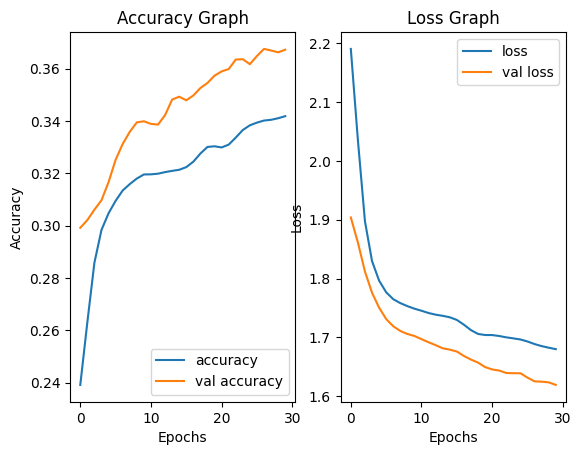

In [17]:
smooth_accuracy = gaussian_filter1d(accuracy, sigma=1)
smooth_val_accuracy = gaussian_filter1d(val_accuracy, sigma=1)
smooth_loss = gaussian_filter1d(loss, sigma=1)
smooth_val_loss = gaussian_filter1d(val_loss, sigma=1)

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(smooth_accuracy, label='accuracy')
plt.plot(smooth_val_accuracy, label='val accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(smooth_loss, label='loss')
plt.plot(smooth_val_loss, label='val loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Fine Tune Model

In [18]:
base_model = emotion_model.layers[2]  # MobileNetV2 layer
for layer in base_model.layers[-30:]:  # Unfreeze last 30 layers
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

In [19]:
optimizer = Adam(learning_rate=0.0001) # Lower learning rate

emotion_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) # Stop sooner
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2) # More aggressive LR reduction

In [20]:
emotion_model_info_phase2 = emotion_model.fit(
    train_generator,
    initial_epoch=30,
    epochs=50,  # Total epochs (30 + 20)
    validation_data=validation_generator,
    callbacks=[early_stopping, lr_scheduler])

Epoch 31/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 49ms/step - accuracy: 0.3303 - loss: 1.6949 - val_accuracy: 0.3704 - val_loss: 1.6235 - learning_rate: 1.0000e-04
Epoch 32/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.3703 - loss: 1.6318 - val_accuracy: 0.3638 - val_loss: 1.6849 - learning_rate: 1.0000e-04
Epoch 33/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.3866 - loss: 1.6061 - val_accuracy: 0.3431 - val_loss: 1.8231 - learning_rate: 1.0000e-04
Epoch 34/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.3956 - loss: 1.5863 - val_accuracy: 0.4221 - val_loss: 1.5048 - learning_rate: 5.0000e-05
Epoch 35/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.4118 - loss: 1.5592 - val_accuracy: 0.4211 - val_loss: 1.5026 - learning_rate: 5.0000e-05
Epoch 36/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 34s 37ms/step - accuracy: 0.4206 - loss: 1.5535 - val_accuracy: 0.4310 - val_loss: 1.5024 - learning_rate: 5.0000e-05
Epoch 37/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 33s 3

# Accuracy and Loss Evaluation

In [21]:
emotion_model.evaluate(validation_generator)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4738 - loss: 1.3926


[1.3848150968551636, 0.47701308131217957]

# Visualising

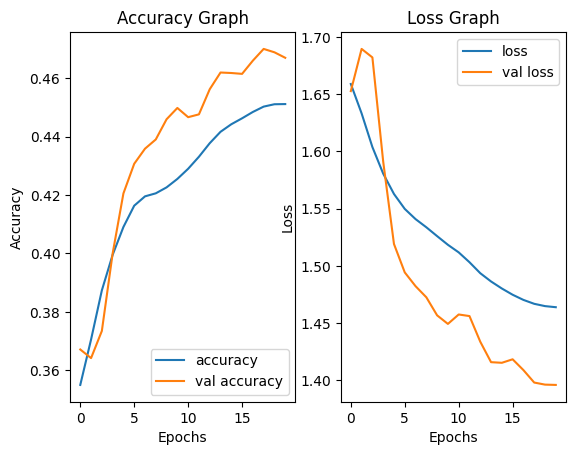

In [22]:
accuracy = emotion_model_info_phase2.history['accuracy']
val_accuracy = emotion_model_info_phase2.history['val_accuracy']
loss = emotion_model_info_phase2.history['loss']
val_loss = emotion_model_info_phase2.history['val_loss']

smooth_accuracy = gaussian_filter1d(accuracy, sigma=1)
smooth_val_accuracy = gaussian_filter1d(val_accuracy, sigma=1)
smooth_loss = gaussian_filter1d(loss, sigma=1)
smooth_val_loss = gaussian_filter1d(val_loss, sigma=1)

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(smooth_accuracy, label='accuracy')
plt.plot(smooth_val_accuracy, label='val accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(smooth_loss, label='loss')
plt.plot(smooth_val_loss, label='val loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Overall Visualisation

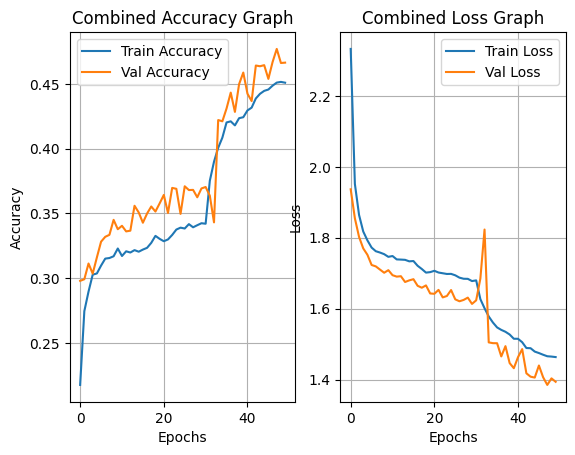

In [23]:
# Combine metrics
accuracy = emotion_model_info_phase1.history['accuracy'] + emotion_model_info_phase2.history['accuracy']
val_accuracy = emotion_model_info_phase1.history['val_accuracy'] + emotion_model_info_phase2.history['val_accuracy']
loss = emotion_model_info_phase1.history['loss'] + emotion_model_info_phase2.history['loss']
val_loss = emotion_model_info_phase1.history['val_loss'] + emotion_model_info_phase2.history['val_loss']

plt.subplot(1, 2, 1)
plt.plot(accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Val Accuracy')
plt.title('Combined Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Combined Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# Save model and training history

In [24]:
# Ensure the directory exists
os.makedirs('models_mobileNetv2', exist_ok=True)

In [25]:
emotion_model.save('models_mobileNetv2/emotion_model.h5')

with open('models_mobileNetv2/emotion_training_history_phase1.json', 'w') as f:
    json.dump(emotion_model_info_phase1.history, f)

with open('models_mobileNetv2/emotion_training_history_phase2.json', 'w') as f:
    json.dump(emotion_model_info_phase2.history, f)

In [26]:
from google.colab import files

folder_path = 'models_mobileNetv2'

shutil.make_archive(folder_path, 'zip', folder_path)

files.download(folder_path + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Model Evaluation

In [9]:
# Load model
emotion_model = load_model('models/emotion_model_mobilenet_v2_48.h5')


In [ ]:
# Load model training history
with open('models/emotion_training_history_mobilenet_v2.json', 'r') as f:
    emotion_model_info_history = json.load(f)

In [28]:
# Predict class probabilities
y_pred_probs = emotion_model.predict(validation_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred, target_names=class_labels))


225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step
              precision    recall  f1-score   support

       angry       0.13      0.11      0.12       958
     disgust       0.00      0.00      0.00       111
        fear       0.14      0.04      0.06      1024
       happy       0.25      0.33      0.28      1774
     neutral       0.17      0.22      0.19      1233
         sad       0.17      0.13      0.15      1247
    surprise       0.12      0.15      0.14       831

    accuracy                           0.18      7178
   macro avg       0.14      0.14      0.13      7178
weighted avg       0.17      0.18      0.17      7178



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


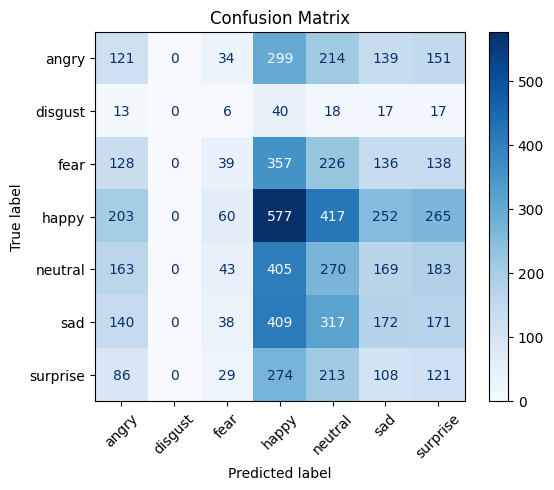

In [29]:
# Get the true labels and predicted labels for the validation set
validation_true_labels = validation_generator.classes
validation_pred_probs = emotion_model.predict(validation_generator)
validation_pred_labels = np.argmax(validation_pred_probs, axis=1)

# Compute the confusion matrix
matrix = confusion_matrix(validation_true_labels, validation_pred_labels)
class_labels = list(train_generator.class_indices.keys())
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step


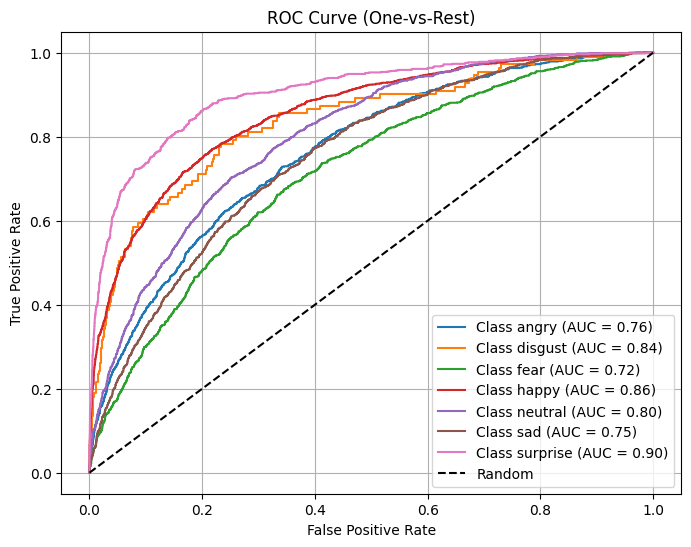

In [10]:
n_val_samples = validation_generator.samples
n_classes = validation_generator.num_classes

# Extract all data from the generator
# Set steps to cover the full dataset
X_test, y_test_onehot = [], []

for i in range(int(np.ceil(n_val_samples / validation_generator.batch_size))):
    x_batch, y_batch = next(validation_generator)
    X_test.append(x_batch)
    y_test_onehot.append(y_batch)

# Concatenate all batches
X_test = np.concatenate(X_test)
y_test_onehot = np.concatenate(y_test_onehot)

# Convert one-hot labels to class indices (e.g., 0–6)
y_test = np.argmax(y_test_onehot, axis=1)

y_pred_probs = emotion_model.predict(X_test)  # shape: (n_samples, n_classes)

# --- 4. Binarize the true labels ---
n_classes = y_pred_probs.shape[1]
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# --- 5. Compute ROC curves and AUCs ---
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 6. Plot ROC curves ---
class_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

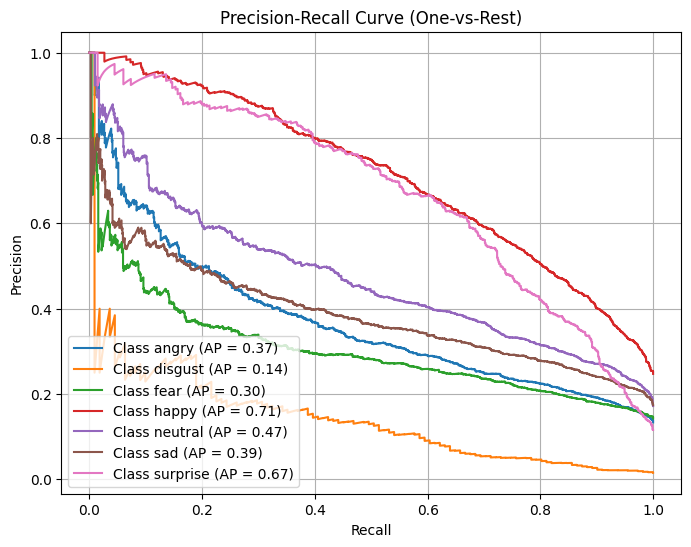

In [11]:
# Compute Precision-Recall curves and average precision
precision = {}
recall = {}
avg_precision = {}

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    avg_precision[i] = average_precision_score(y_test_bin[:, i], y_pred_probs[:, i])

# Plot Precision-Recall curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'Class {class_labels[i]} (AP = {avg_precision[i]:.2f})')

plt.title('Precision-Recall Curve (One-vs-Rest)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


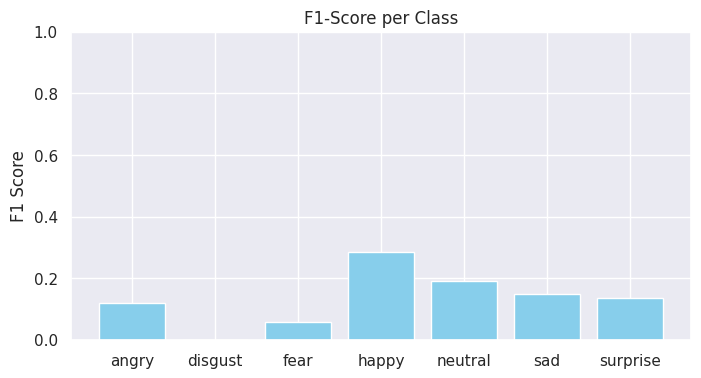

In [37]:
# Compute F1-score for each class
f1 = f1_score(y_true, y_pred, average=None)

# Plot F1-score per class
plt.figure(figsize=(8, 4))
plt.bar(class_labels, f1, color='skyblue')
plt.title('F1-Score per Class')
plt.ylabel('F1 Score')
plt.ylim([0, 1])
plt.grid(True, axis='y')
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


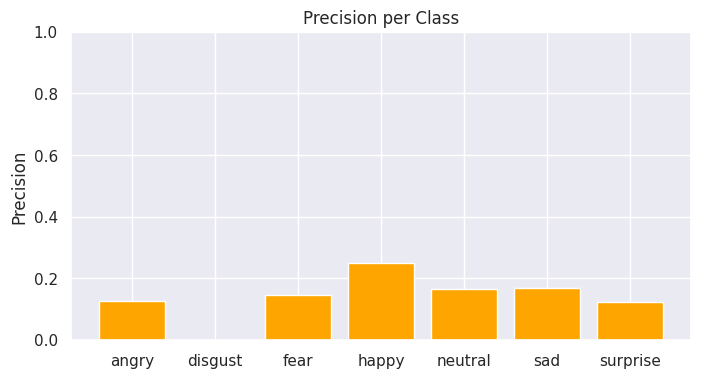

In [38]:
# Compute precision for each class
precision_scores = precision_score(y_true, y_pred, average=None)

plt.figure(figsize=(8, 4))
plt.bar(class_labels, precision_scores, color='orange')
plt.title('Precision per Class')
plt.ylabel('Precision')
plt.ylim([0, 1])
plt.grid(True, axis='y')
plt.show()


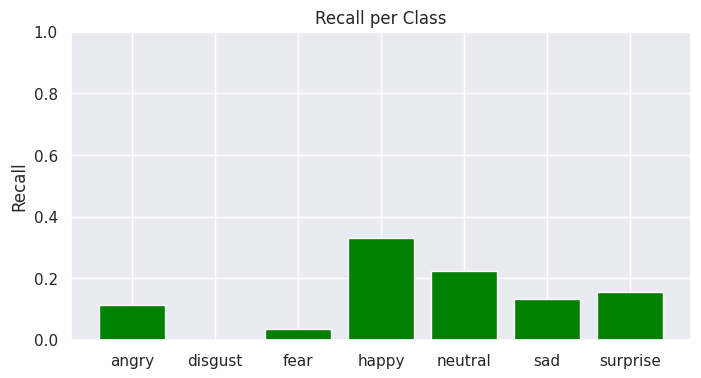

In [39]:
# Compute recall for each class
recall_scores = recall_score(y_true, y_pred, average=None)

plt.figure(figsize=(8, 4))
plt.bar(class_labels, recall_scores, color='green')
plt.title('Recall per Class')
plt.ylabel('Recall')
plt.ylim([0, 1])
plt.grid(True, axis='y')
plt.show()
